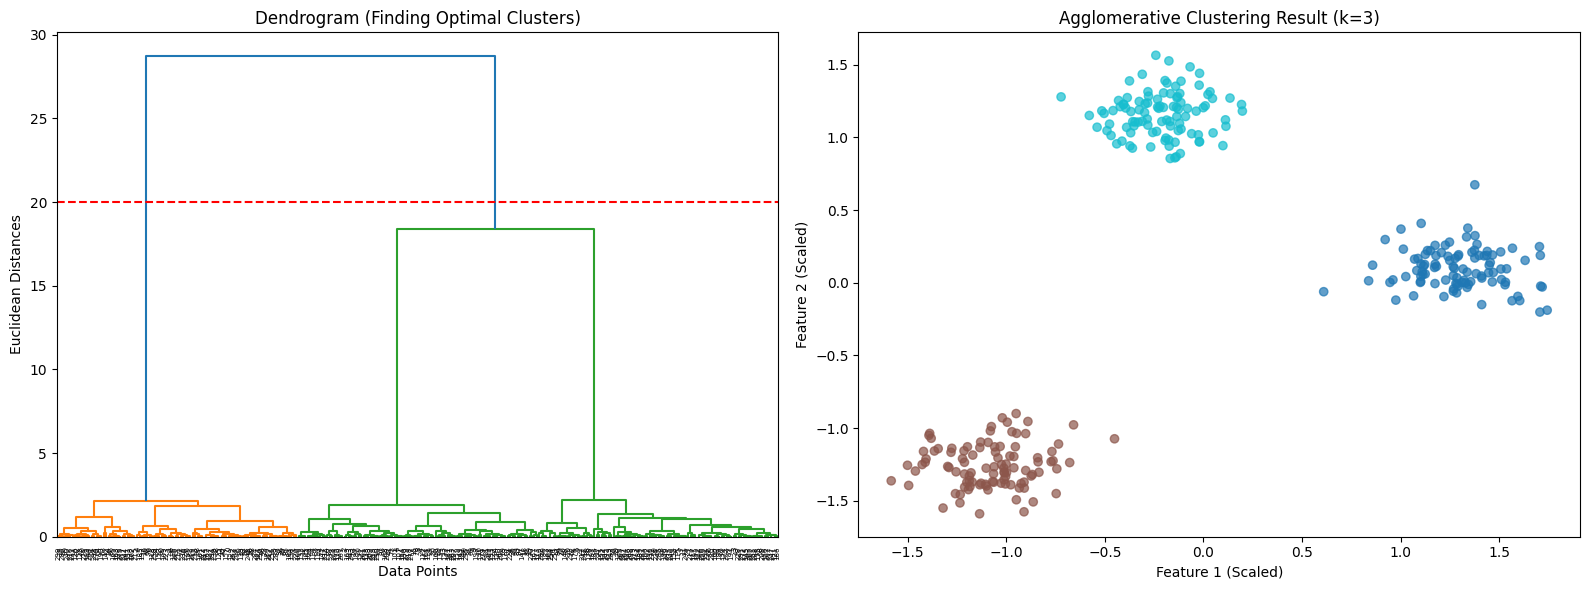

শনাক্তকৃত ক্লাস্টার আইডি সমূহ: [0 1 2]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch

# ১. ডেটাসেট তৈরি ও স্কেলিং
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ২. ভিজ্যুয়ালাইজেশন এর জন্য সাবপ্লট তৈরি
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ৩. ডেনড্রোগ্রাম তৈরি (বাম দিকের গ্রাফ)
ax1.set_title("Dendrogram (Finding Optimal Clusters)")
# linkage তৈরি করা হচ্ছে
linkage_matrix = sch.linkage(X_scaled, method='ward')
dendrogram = sch.dendrogram(linkage_matrix, ax=ax1)

# ডেনড্রোগ্রামে একটি আড়াআড়ি রেখা টেনে ক্লাস্টার সংখ্যা নির্ধারণ (কাটিং লাইন)
# এখানে ২০ উচ্চতায় কাটলে আমরা ৩টি লম্বালম্বি লাইন পাই, অর্থাৎ ৩টি ক্লাস্টার
ax1.axhline(y=20, color='r', linestyle='--')
ax1.set_xlabel('Data Points')
ax1.set_ylabel('Euclidean Distances')

# ৪. ডেনড্রোগ্রাম থেকে পাওয়া ক্লাস্টার সংখ্যা দিয়ে মডেল ফিট করা (ডান দিকের গ্রাফ)
# আমরা ডেনড্রোগ্রামে দেখলাম ৩টি বড় শাখা আছে, তাই n_clusters=3
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = hc.fit_predict(X_scaled)

ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='tab10', alpha=0.7)
ax2.set_title("Agglomerative Clustering Result (k=3)")
ax2.set_xlabel("Feature 1 (Scaled)")
ax2.set_ylabel("Feature 2 (Scaled)")

plt.tight_layout()
plt.show()

# ৫. ক্লাস্টার সংখ্যা প্রিন্ট করা
print(f"শনাক্তকৃত ক্লাস্টার আইডি সমূহ: {np.unique(clusters)}")